### PySpark Otomoto Demo

Źródło danych: https://www.kaggle.com/datasets/szymoncyperski/car-sales-offers-from-otomotopl-2023


In [8]:
import os
os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

**Teoria:** Powyżej importujemy niezbędne biblioteki. `SparkSession` to główny punkt wejścia do funkcjonalności DataFrame i SQL w Sparku (od wersji 2.0). Moduł `functions` dostarcza wbudowane funkcje operujące na kolumnach, a `matplotlib.pyplot` posłuży nam do późniejszej wizualizacji danych.


In [9]:
spark = SparkSession.builder \
    .appName("Otomoto Demo") \
    .getOrCreate()


**Teoria:** Tworzymy sesję Sparka. `builder` używa wzorca projektowego Builder do skonfigurowania sesji. `getOrCreate()` tworzy nową sesję lub pobiera istniejącą, co jest bezpieczne przy wielokrotnym uruchamianiu notatnika.


In [10]:
df = spark.read.option("header", True) \
    .option("delimiter", ";") \
    .option("inferSchema", False) \
    .csv("otomoto_offers_eng_23-04-2023.csv")


**Teoria:** Wczytywanie danych. Spark używa leniwego ewaluowania (lazy evaluation) - dane nie są fizycznie wczytywane w tym momencie, tworzony jest tylko plan wykonania (DAG). Ustawiamy `header=True` ponieważ nasz plik CSV ma nagłówki, oraz określamy separator jako średnik `;`.


In [11]:
df.show()

+----------+-------------------+--------------------+------+--------+-----------------+------------------------+--------------------+---------------+--------+---------------------------+-------------+-------------+---------------+---------------+----------+-------------------+--------------+------+------------+-------------+---------------+---------------+---------+----------+---------------------+-----+--------------------+------------------------+----------+-----+---------------------------+------------+-----------+--------------------------+--------------------------+--------------+-------------+----------------------+----------------------------------+----------------------------+----------------------+---------------------+--------------+------------------------------------+-------------------+----------------+--------------+---------------+------------+----+-------------------+-------------+----------------+------------------+------------------+------------------+----------------

**Teoria:** `show()` to akcja (action), która uruchamia wykonanie obliczeń w Sparku. Dopiero teraz plik jest odczytywany, a wynik prezentowany na ekranie.


In [12]:
df.filter(F.col("vehicle_brand") == "Volvo").show()

+----------+-------------------+--------------------+------+--------+-----------------+------------------------+--------------------+---------------+--------+---------------------------+-------------+-------------+-------------+---------------+----------+-------------------+---------+------+------------+-------------+---------------+---------------+--------+----------+---------------------+-----+--------------------+------------------------+----------+-----+---------------------------+------------+-----------+--------------------------+--------------------------+--------------+-------------+----------------------+----------------------------------+----------------------------+----------------------+---------------------+--------------+------------------------------------+-------------------+----------------+--------------+---------------+------------+----+-------------------+-------------+----------------+------------------+------------------+------------------+-----------------+------

In [13]:
df = df.withColumn("price_num",
                   F.regexp_replace(F.col("price"), r"[^\d]", "").cast("double"))

df = df.withColumn("mileage_km",
                   F.regexp_replace(F.col("mileage"), r"[^\d]", "").cast("integer"))

df = df.withColumn("production_year_int",
                   F.regexp_replace(F.col("production_year"), r"[^\d]", "").cast("integer"))

df = df.withColumn("engine_cc",
                   F.regexp_replace(F.col("engine_displacement"), r"[^\d]", "").cast("integer"))

df = df.withColumn("power_hp",
                   F.regexp_replace(F.col("power"), r"[^\d]", "").cast("integer"))

df = df.withColumn("fuel_clean",
                   F.lower(F.trim(F.col("fuel_type"))))

In [14]:
df.select("vehicle_brand", "vehicle_model", "price_num", "mileage_km",
          "production_year_int", "engine_cc", "power_hp", "fuel_clean") \
  .show(10, truncate=False)

+-------------+-------------+---------+----------+-------------------+---------+--------+--------------+
|vehicle_brand|vehicle_model|price_num|mileage_km|production_year_int|engine_cc|power_hp|fuel_clean    |
+-------------+-------------+---------+----------+-------------------+---------+--------+--------------+
|Volvo        |V70          |23200.0  |304000    |2010               |15603    |109     |diesel        |
|Honda        |Accord       |16800.0  |236000    |2005               |19983    |155     |gasoline      |
|Mercedes-Benz|Klasa X      |249900.0 |73000     |2019               |29873    |258     |diesel        |
|Toyota       |Avensis      |16499.0  |220000    |2005               |17943    |129     |gasoline      |
|Ford         |C-MAX        |29900.0  |179058    |2012               |19973    |140     |diesel        |
|Peugeot      |208          |80900.0  |1         |2023               |11993    |75      |gasoline      |
|Kia          |Sportage     |74770.0  |100420    |2018 

**Teoria:** `select()` to transformacja, która działa jak w SQL - pozwala wybrać podzbiór kolumn. Zmniejsza to ilość przetwarzanych danych w dalszych krokach.


In [15]:
avg_brand = df.groupBy("vehicle_brand") \
              .agg(F.round(F.avg("price_num"), 2).alias("avg_price")) \
              .orderBy(F.col("avg_price").desc())

print("Średnia cena per marka")
avg_brand.show(20, truncate=False)

Średnia cena per marka
+-------------+---------+
|vehicle_brand|avg_price|
+-------------+---------+
|Lamborghini  |1259686.6|
|Ferrari      |1198403.2|
|McLaren      |907240.86|
|Bentley      |668690.83|
|Aston Martin |572773.5 |
|Alpine       |495972.0 |
|Rolls-Royce  |491550.0 |
|KTM          |389000.0 |
|BMW-ALPINA   |371348.71|
|Porsche      |347182.53|
|Geely        |341940.0 |
|RAM          |337416.58|
|Maxus        |272044.88|
|Skywell      |269990.0 |
|Maybach      |264999.0 |
|Tesla        |219432.41|
|GMC          |208008.25|
|Land Rover   |200343.88|
|Maserati     |195856.73|
|Cupra        |191332.82|
+-------------+---------+
only showing top 20 rows


In [ ]:
fuel_count = df.groupBy("fuel_clean").count()
print("Liczba ogłoszeń wg rodzaju paliwa")
fuel_count.show()

Liczba ogłoszeń wg rodzaju paliwa
+--------------+------+
|    fuel_clean| count|
+--------------+------+
|      gasoline|101165|
|        diesel| 88624|
|gasoline + lpg|  7419|
|        hybrid|  7527|
|gasoline + cng|    96|
|      electric|  3373|
|      hydrogen|     1|
+--------------+------+



In [16]:
df.createOrReplaceTempView("cars")

In [17]:
# SQL: zależność mocy i pojemności od ceny
spark.sql("""
    SELECT vehicle_brand,
           ROUND(AVG(power_hp), 1) AS avg_power,
           ROUND(AVG(engine_cc), 1) AS avg_cc,
           ROUND(AVG(price_num), 1) AS avg_price
    FROM cars
    GROUP BY vehicle_brand
    ORDER BY avg_power DESC
""").show()

+-------------+---------+-------+---------+
|vehicle_brand|avg_power| avg_cc|avg_price|
+-------------+---------+-------+---------+
|      Ferrari|    645.1|45881.5|1198403.2|
|      McLaren|    644.3|39107.3| 907240.9|
|  Lamborghini|    624.0|51833.7|1259686.6|
|   BMW-ALPINA|    547.5|41978.3| 371348.7|
|      Bentley|    544.7|52697.3| 668690.8|
| Aston Martin|    529.6|55954.3| 572773.5|
|        Tesla|    465.7|   NULL| 219432.4|
|      Maybach|    455.0|46633.0| 264999.0|
|          RAM|    413.3|56080.4| 337416.6|
|     Polestar|    408.0|   NULL| 110000.0|
|  Rolls-Royce|    401.3|67274.4| 491550.0|
|     Maserati|    390.6|30989.6| 195856.7|
|      Porsche|    368.8|32634.3| 347182.5|
|          KTM|    362.0|19843.0| 389000.0|
|        Dodge|    351.6|47786.0| 147074.5|
|          GMC|    330.5|50382.2| 208008.3|
|     Cadillac|    315.4|48704.6| 129155.3|
|      Genesis|    300.0|24893.0| 136300.0|
|      Mercury|    283.3|62836.3|  68233.3|
|       Alpine|    276.0|17983.0

In [18]:
df.groupBy("production_year_int") \
  .count() \
  .orderBy(F.col("production_year_int").desc()) \
  .show()

+-------------------+-----+
|production_year_int|count|
+-------------------+-----+
|               2023| 4260|
|               2022| 4452|
|               2021| 2563|
|               2020| 2542|
|               2019| 4604|
|               2018| 4939|
|               2017| 4688|
|               2016| 3864|
|               2015| 3552|
|               2014| 3315|
|               2013| 3068|
|               2012| 3242|
|               2011| 3302|
|               2010| 3016|
|               2009| 2938|
|               2008| 2844|
|               2007| 2624|
|               2006| 2029|
|               2005| 1702|
|               2004| 1189|
+-------------------+-----+
only showing top 20 rows


In [19]:
# Średnia cena i przebieg per marka i model
df.groupBy("vehicle_brand", "vehicle_model") \
  .agg(
      F.round(F.avg("price_num"), 2).alias("avg_price"),
      F.round(F.avg("mileage_km"), 2).alias("avg_mileage")
  ) \
  .orderBy(F.col("avg_price").desc()) \
  .show(20, truncate=False)

+-------------+-------------+----------+-----------+
|vehicle_brand|vehicle_model|avg_price |avg_mileage|
+-------------+-------------+----------+-----------+
|Ferrari      |SF90 Stradale|2843168.0 |1374.33    |
|Ferrari      |812 GTS      |2750000.0 |2000.0     |
|Lamborghini  |Aventador    |2064500.0 |19563.5    |
|Lamborghini  |Urus         |1754500.0 |7100.0     |
|McLaren      |720S Coupe   |1692000.0 |8900.0     |
|Ferrari      |812 Superfast|1570000.0 |23000.0    |
|Ferrari      |GTC4Lusso    |1299000.0 |33150.0    |
|Mercedes-Benz|SLS          |1250000.0 |7663.0     |
|Rolls-Royce  |Phantom      |1225000.0 |22000.0    |
|Lamborghini  |Huracan      |1151037.38|22138.63   |
|Ferrari      |488          |1118250.0 |25542.25   |
|Ferrari      |Testarossa   |1080000.0 |23374.0    |
|Bentley      |Bentayga     |1004333.33|40862.0    |
|Ferrari      |512          |999000.0  |52000.0    |
|Aston Martin |Vantage      |995000.0  |5000.0     |
|BMW          |XM           |985530.5  |4.5   

In [20]:
# zależność ceny od przebiegu
price_mileage = df.select("price_num", "mileage_km") \
                  .where((F.col("price_num").isNotNull()) & (F.col("mileage_km").isNotNull()))

Wizualizacja scatter zapisana jako scatter_price_mileage.png


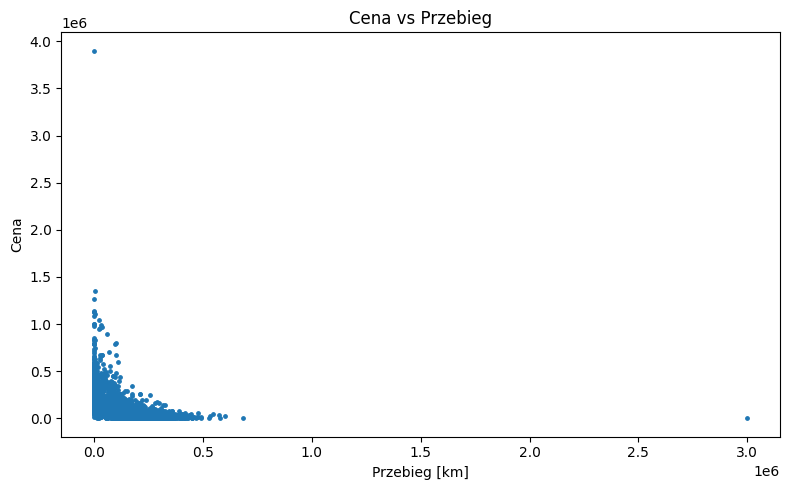

In [21]:
pdf_scatter = price_mileage.sample(fraction=0.1, seed=42).toPandas()

plt.figure(figsize=(8,5))
plt.scatter(pdf_scatter["mileage_km"], pdf_scatter["price_num"], s=6)
plt.title("Cena vs Przebieg")
plt.xlabel("Przebieg [km]")
plt.ylabel("Cena")
plt.tight_layout()
plt.savefig("scatter_price_mileage.png")

print("Wizualizacja scatter zapisana jako scatter_price_mileage.png")

**Teoria:** `toPandas()` to akcja, która zbiera (collect) wszystkie dane na partycjach roboczych i przesyła je na węzeł główny (Driver), konwertując do struktury Pandas DataFrame. Uwaga: Można tego używać tylko na małych zbiorach (po limitowaniu np. top 10), w przeciwnym razie braknie pamięci RAM na Driverze!


---
# Zadanie samodzielne: Analiza Przestępczości w Chicago

Poniżej znajduje się miejsce na realizację zadania z analizy danych przy użyciu PySpark na zbiorze *Chicago Crimes* (około 50 000 ostatnich zdarzeń). Twoim celem jest przygotowanie, wyczyszczenie oraz zanalizowanie tych danych z wykorzystaniem zaawansowanych optymalizacji dostępnych w Sparku.

### Wymagania:
1. **Wczytanie i Czyszczenie Danych:** Wczytaj pobrany plik `chicago_crimes_sample.csv`. Usuń ewentualne duplikaty, wiersze z brakami danych (szczególnie w kluczowych kolumnach) i odfiltruj/napraw błędne daty.
2. **UDF i Pora Dnia:** Dodaj nową kolumnę z klasyfikacją pory dnia (np. noc, dzień, wieczór) utworzoną za pomocą User Defined Function (UDF) w oparciu o godzinę z kolumny `Date`.
3. **Optymalizacja i Partycjonowanie:** Zoptymalizuj przetwarzanie. Zastanów się, w których momentach użyć `cache()`. Przy dołączaniu mniejszych tabel słownikowych (jeśli byś je tworzył), wykorzystaj *broadcast join*. Ostatecznie zapisz przefiltrowane dane do formatu **Parquet** z podziałem na partycje według roku (`Year`).
4. **Analiza i Plany Zapytań:** Przeprowadź analizę statystyczną przestępstw (np. jakiego typu przestępstwa są najpopularniejsze w konkretnych lokacjach, o konkretnym czasie). Wykorzystaj funkcję `.explain()` aby udokumentować plan zapytania Sparka dla najcięższej agregacji.
5. *(Opcjonalnie)* **Uczenie Maszynowe (MLlib):** Spróbuj zbudować i wytrenować prosty model wieloklasowy, przewidujący rodzaj przestępstwa (`Primary Type`) na podstawie innych atrybutów, jak lokacja, godzina, arrest itp.

In [23]:
# Tutaj wpisz swój kod zliczający, czytający plik itp.
# Podpowiedź krok 1:
# df_crimes = spark.read.option("header", True).csv("chicago_crimes_sample.csv")
# df_crimes.show(5)

import os

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, trim, upper, lower, when, count, desc, asc, hour, year,
    to_timestamp, coalesce, broadcast, udf
)
from pyspark.sql.types import StringType, IntegerType, DoubleType, BooleanType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

INPUT_PATH = "/content/chicago_crimes_sample.csv"
OUTPUT_PARQUET_PATH = "/content/chicago_crimes_parquet"
RUN_ML = True

spark = (
    SparkSession.builder
    .appName("Chicago Crimes Analysis")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

df_raw = (
    spark.read
    .option("header", True)
    .option("delimiter", ",")
    .option("inferSchema", True)
    .option("multiLine", True)
    .option("quote", "\"")
    .option("escape", "\"")
    .csv(INPUT_PATH)
)

raw_count = df_raw.count()

def normalize_column_name(name):
    return (
        name.strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
        .replace(".", "")
        .replace("(", "")
        .replace(")", "")
    )

df = df_raw

for old_name in df.columns:
    df = df.withColumnRenamed(old_name, normalize_column_name(old_name))

required_columns = ["id", "date", "primary_type", "location_description"]
missing_columns = [c for c in required_columns if c not in df.columns]

if missing_columns:
    raise ValueError(f"Brakuje wymaganych kolumn: {missing_columns}")

df_cleaned = df.dropDuplicates()

text_columns = [
    "case_number", "block", "iucr", "primary_type", "description",
    "location_description", "fbi_code", "location"
]

for c in text_columns:
    if c in df_cleaned.columns:
        df_cleaned = df_cleaned.withColumn(c, trim(col(c).cast(StringType())))
        df_cleaned = df_cleaned.withColumn(
            c,
            when(lower(col(c)).isin("", "null", "none", "nan", "na", "n/a"), None)
            .otherwise(col(c))
        )

df_cleaned = df_cleaned.dropna(subset=required_columns)

df_cleaned = df_cleaned.withColumn("id", col("id").cast(IntegerType()))
df_cleaned = df_cleaned.filter(col("id").isNotNull())
df_cleaned = df_cleaned.dropDuplicates(["id"])

df_cleaned = df_cleaned.withColumn("primary_type", upper(col("primary_type")))
df_cleaned = df_cleaned.withColumn("location_description", upper(col("location_description")))

if "description" in df_cleaned.columns:
    df_cleaned = df_cleaned.withColumn("description", upper(col("description")))

df_cleaned = df_cleaned.withColumn(
    "date_parsed",
    coalesce(
        to_timestamp(col("date").cast(StringType()), "yyyy-MM-dd'T'HH:mm:ss.SSS"),
        to_timestamp(col("date").cast(StringType()), "yyyy-MM-dd'T'HH:mm:ss"),
        to_timestamp(col("date").cast(StringType()), "yyyy-MM-dd HH:mm:ss"),
        to_timestamp(col("date").cast(StringType()), "MM/dd/yyyy hh:mm:ss a"),
        to_timestamp(col("date").cast(StringType()), "MM/dd/yyyy HH:mm:ss"),
        to_timestamp(col("date").cast(StringType()))
    )
)

df_cleaned = df_cleaned.filter(col("date_parsed").isNotNull())
df_cleaned = df_cleaned.withColumn("year", year(col("date_parsed")).cast(IntegerType()))
df_cleaned = df_cleaned.filter(col("year").isNotNull())

integer_columns = [
    "beat", "district", "ward", "community_area",
    "x_coordinate", "y_coordinate"
]

double_columns = ["latitude", "longitude"]

for c in integer_columns:
    if c in df_cleaned.columns:
        df_cleaned = df_cleaned.withColumn(c, col(c).cast(IntegerType()))

for c in double_columns:
    if c in df_cleaned.columns:
        df_cleaned = df_cleaned.withColumn(c, col(c).cast(DoubleType()))

for c in ["arrest", "domestic"]:
    if c in df_cleaned.columns:
        df_cleaned = df_cleaned.withColumn(
            c,
            when(lower(col(c).cast(StringType())).isin("true", "1", "yes", "y"), True)
            .when(lower(col(c).cast(StringType())).isin("false", "0", "no", "n"), False)
            .otherwise(None)
            .cast(BooleanType())
        )

fill_values = {}

for c in ["description", "block", "fbi_code"]:
    if c in df_cleaned.columns:
        fill_values[c] = "UNKNOWN"

for c in ["district", "ward", "community_area", "beat"]:
    if c in df_cleaned.columns:
        fill_values[c] = -1

for c in ["latitude", "longitude"]:
    if c in df_cleaned.columns:
        fill_values[c] = 0.0

for c in ["arrest", "domestic"]:
    if c in df_cleaned.columns:
        fill_values[c] = False

df_cleaned = df_cleaned.fillna(fill_values)

def classify_time_of_day(hour_value):
    if hour_value is None:
        return "UNKNOWN"

    try:
        hour_value = int(hour_value)
    except Exception:
        return "UNKNOWN"

    if 0 <= hour_value <= 5:
        return "NOC"
    if 6 <= hour_value <= 11:
        return "RANO"
    if 12 <= hour_value <= 17:
        return "DZIEN"
    if 18 <= hour_value <= 23:
        return "WIECZOR"

    return "UNKNOWN"

classify_time_of_day_udf = udf(classify_time_of_day, StringType())

df_cleaned = df_cleaned.withColumn("crime_hour", hour(col("date_parsed")))
df_cleaned = df_cleaned.withColumn("time_of_day", classify_time_of_day_udf(col("crime_hour")))

crime_category_data = [
    ("THEFT", "PROPERTY", "MEDIUM"),
    ("BATTERY", "VIOLENT", "HIGH"),
    ("CRIMINAL DAMAGE", "PROPERTY", "MEDIUM"),
    ("NARCOTICS", "DRUG", "MEDIUM"),
    ("ASSAULT", "VIOLENT", "HIGH"),
    ("BURGLARY", "PROPERTY", "HIGH"),
    ("MOTOR VEHICLE THEFT", "PROPERTY", "HIGH"),
    ("ROBBERY", "VIOLENT", "HIGH"),
    ("DECEPTIVE PRACTICE", "FINANCIAL", "MEDIUM"),
    ("OTHER OFFENSE", "OTHER", "LOW"),
    ("CRIMINAL TRESPASS", "PUBLIC_ORDER", "LOW"),
    ("WEAPONS VIOLATION", "WEAPON", "HIGH"),
    ("PROSTITUTION", "PUBLIC_ORDER", "LOW"),
    ("OFFENSE INVOLVING CHILDREN", "OTHER", "HIGH"),
    ("PUBLIC PEACE VIOLATION", "PUBLIC_ORDER", "LOW"),
    ("SEX OFFENSE", "SEXUAL", "HIGH"),
    ("CRIM SEXUAL ASSAULT", "SEXUAL", "HIGH"),
    ("INTERFERENCE WITH PUBLIC OFFICER", "PUBLIC_ORDER", "MEDIUM"),
    ("HOMICIDE", "VIOLENT", "HIGH"),
    ("ARSON", "PROPERTY", "HIGH"),
    ("KIDNAPPING", "VIOLENT", "HIGH"),
    ("GAMBLING", "PUBLIC_ORDER", "LOW"),
    ("LIQUOR LAW VIOLATION", "PUBLIC_ORDER", "LOW"),
    ("INTIMIDATION", "VIOLENT", "MEDIUM"),
    ("STALKING", "VIOLENT", "MEDIUM"),
    ("OBSCENITY", "PUBLIC_ORDER", "LOW"),
    ("CONCEALED CARRY LICENSE VIOLATION", "WEAPON", "MEDIUM"),
    ("HUMAN TRAFFICKING", "VIOLENT", "HIGH"),
    ("PUBLIC INDECENCY", "PUBLIC_ORDER", "LOW"),
    ("NON-CRIMINAL", "NON_CRIMINAL", "LOW"),
    ("NON-CRIMINAL SUBJECT SPECIFIED", "NON_CRIMINAL", "LOW"),
    ("OTHER NARCOTIC VIOLATION", "DRUG", "MEDIUM")
]

crime_category_df = spark.createDataFrame(
    crime_category_data,
    ["primary_type", "crime_category", "severity"]
)

df_cleaned = (
    df_cleaned
    .join(broadcast(crime_category_df), on="primary_type", how="left")
    .fillna({"crime_category": "OTHER", "severity": "UNKNOWN"})
)

df_cleaned = df_cleaned.repartition("year").cache()
clean_count = df_cleaned.count()

counts_summary = spark.createDataFrame(
    [
        ("po_wczytaniu", raw_count),
        ("po_czyszczeniu", clean_count)
    ],
    ["etap", "liczba_wierszy"]
)

counts_summary.show(truncate=False)

(
    df_cleaned.write
    .mode("overwrite")
    .partitionBy("year")
    .parquet(OUTPUT_PARQUET_PATH)
)

crimes = spark.read.parquet(OUTPUT_PARQUET_PATH).cache()
_ = crimes.count()

top_crimes = (
    crimes
    .groupBy("primary_type")
    .agg(count("*").alias("crime_count"))
    .orderBy(desc("crime_count"))
)

crimes_by_time = (
    crimes
    .groupBy("time_of_day")
    .agg(count("*").alias("crime_count"))
    .orderBy(desc("crime_count"))
)

crimes_by_location = (
    crimes
    .groupBy("location_description")
    .agg(count("*").alias("crime_count"))
    .orderBy(desc("crime_count"))
)

crimes_by_year = (
    crimes
    .groupBy("year")
    .agg(count("*").alias("crime_count"))
    .orderBy(asc("year"))
)

crimes_by_type_and_time = (
    crimes
    .groupBy("primary_type", "time_of_day")
    .agg(count("*").alias("crime_count"))
    .orderBy(desc("crime_count"))
)

category_stats = (
    crimes
    .groupBy("crime_category", "severity")
    .agg(count("*").alias("crime_count"))
    .orderBy(desc("crime_count"))
)

advanced_stats = (
    crimes
    .groupBy("primary_type", "location_description", "time_of_day")
    .agg(count("*").alias("crime_count"))
    .orderBy(desc("crime_count"))
)

top_crimes.show(10, truncate=False)
crimes_by_time.show(truncate=False)
crimes_by_location.show(10, truncate=False)
crimes_by_year.show(truncate=False)
crimes_by_type_and_time.show(20, truncate=False)
category_stats.show(truncate=False)
advanced_stats.show(30, truncate=False)

if "arrest" in crimes.columns:
    arrests_by_type = (
        crimes
        .groupBy("primary_type", "arrest")
        .agg(count("*").alias("crime_count"))
        .orderBy(desc("crime_count"))
    )

    arrests_by_type.show(20, truncate=False)

top_crimes.explain(mode="formatted")
crimes_by_time.explain(mode="formatted")
advanced_stats.explain(mode="formatted")

if RUN_ML:
    label_counts = (
        crimes
        .groupBy("primary_type")
        .agg(count("*").alias("cnt"))
        .filter(col("cnt") >= 30)
    )

    ml_df = crimes.join(
        broadcast(label_counts.select("primary_type")),
        on="primary_type",
        how="inner"
    )

    categorical_candidates = [
        "location_description",
        "time_of_day"
    ]

    numeric_candidates = [
        "crime_hour",
        "district",
        "ward",
        "community_area",
        "latitude",
        "longitude"
    ]

    if "arrest" in ml_df.columns:
        ml_df = ml_df.withColumn("arrest_num", when(col("arrest") == True, 1.0).otherwise(0.0))
        numeric_candidates.append("arrest_num")

    if "domestic" in ml_df.columns:
        ml_df = ml_df.withColumn("domestic_num", when(col("domestic") == True, 1.0).otherwise(0.0))
        numeric_candidates.append("domestic_num")

    categorical_features = [c for c in categorical_candidates if c in ml_df.columns]
    numeric_features = [c for c in numeric_candidates if c in ml_df.columns]

    ml_df = ml_df.select(["primary_type"] + categorical_features + numeric_features)

    ml_fill = {}

    for c in categorical_features:
        ml_fill[c] = "UNKNOWN"

    for c in numeric_features:
        ml_fill[c] = 0.0

    ml_df = ml_df.fillna(ml_fill)

    for c in numeric_features:
        ml_df = ml_df.withColumn(c, col(c).cast(DoubleType()))

    train_df, test_df = ml_df.randomSplit([0.8, 0.2], seed=42)

    label_indexer = StringIndexer(
        inputCol="primary_type",
        outputCol="label",
        handleInvalid="skip"
    )

    feature_indexers = [
        StringIndexer(
            inputCol=c,
            outputCol=f"{c}_idx",
            handleInvalid="keep"
        )
        for c in categorical_features
    ]

    encoder = OneHotEncoder(
        inputCols=[f"{c}_idx" for c in categorical_features],
        outputCols=[f"{c}_vec" for c in categorical_features],
        handleInvalid="keep"
    )

    assembler = VectorAssembler(
        inputCols=[f"{c}_vec" for c in categorical_features] + numeric_features,
        outputCol="features",
        handleInvalid="keep"
    )

    classifier = RandomForestClassifier(
        labelCol="label",
        featuresCol="features",
        numTrees=30,
        maxDepth=8,
        seed=42
    )

    pipeline = Pipeline(
        stages=[
            label_indexer,
            *feature_indexers,
            encoder,
            assembler,
            classifier
        ]
    )

    model = pipeline.fit(train_df)
    predictions = model.transform(test_df)

    predictions.select(
        "primary_type",
        "label",
        "prediction",
        "probability"
    ).show(20, truncate=False)

    accuracy = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="accuracy"
    ).evaluate(predictions)

    f1_score = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="f1"
    ).evaluate(predictions)

    spark.createDataFrame(
        [
            ("accuracy", float(accuracy)),
            ("f1_score", float(f1_score))
        ],
        ["metric", "value"]
    ).show(truncate=False)

df_cleaned.unpersist()
crimes.unpersist()

+--------------+--------------+
|etap          |liczba_wierszy|
+--------------+--------------+
|po_wczytaniu  |50000         |
|po_czyszczeniu|49803         |
+--------------+--------------+

+-------------------+-----------+
|primary_type       |crime_count|
+-------------------+-----------+
|THEFT              |10920      |
|BATTERY            |9253       |
|CRIMINAL DAMAGE    |5497       |
|ASSAULT            |4564       |
|MOTOR VEHICLE THEFT|3886       |
|OTHER OFFENSE      |3459       |
|BURGLARY           |3163       |
|DECEPTIVE PRACTICE |2486       |
|NARCOTICS          |1455       |
|CRIMINAL TRESPASS  |1193       |
+-------------------+-----------+
only showing top 10 rows
+-----------+-----------+
|time_of_day|crime_count|
+-----------+-----------+
|DZIEN      |16037      |
|WIECZOR    |14054      |
|RANO       |10654      |
|NOC        |9058       |
+-----------+-----------+

+--------------------------------------+-----------+
|location_description                  |crim

DataFrame[primary_type: string, id: int, case_number: string, date: string, block: string, iucr: string, description: string, location_description: string, arrest: boolean, domestic: boolean, beat: int, district: int, ward: int, community_area: int, fbi_code: string, x_coordinate: int, y_coordinate: int, updated_on: string, latitude: double, longitude: double, location: string, date_parsed: timestamp, crime_hour: int, time_of_day: string, crime_category: string, severity: string, year: int]